In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('/home/mingxuanzhang/PerturbVAE/PerturbVAE')

from model import *
from utils import *
from dataset import *
from PerturbVAE.trainer import *

In [2]:
data = sc.read_h5ad('/home/mingxuanzhang/PerturbVAE/PerturbVAE/data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [3]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

In [4]:
dataset = PerturbDataset(data)

In [5]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
x = torch.tensor(dataset.X, dtype=torch.float32)
cov = x.T @ x / (x.shape[0] - 1)
cov = cov + torch.eye(cov.shape[0]) * 1e-6  # Add small value to diagonal for numerical stability

In [8]:
import seaborn as sns

In [9]:
def _normalize(cov, eps=1e-12):
    std = np.sqrt(np.diag(cov))
    std[std < eps] = np.inf
    denom = np.outer(std, std)
    corr = cov / denom
    np.fill_diagonal(corr, 1.0)        
    return corr

In [10]:
corr = _normalize(cov.numpy())
corr.shape

(2218, 2218)

In [11]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import squareform

def corr_to_modules(corr: np.ndarray,
                    n_clusters: int | None = None,
                    linkage_method: str = "average",
                    balance: bool = False) -> dict[int, list[int]]:
    dist_vec = squareform(1.0 - np.abs(corr), checks=False)
    Z = linkage(dist_vec, method=linkage_method)
    if balance and n_clusters is not None:
        # dendrogram leaf order keeps similar genes adjacent
        order = leaves_list(Z)
        N = len(order)

        # compute target block sizes: first `n_big` blocks get +1 gene
        base = N // n_clusters
        n_big = N % n_clusters          # #clusters that will be one gene larger

        modules = {}
        idx = 0
        for m in range(1, n_clusters + 1):
            size = base + (1 if m <= n_big else 0)
            modules[m] = order[idx: idx + size].tolist()
            idx += size
        return modules


In [12]:
gene_module_dict = corr_to_modules(corr, n_clusters=16, linkage_method='average', balance=True)
for k, v in gene_module_dict.items():
    print(f"Module {k}: {len(v)} genes")

Module 1: 139 genes
Module 2: 139 genes
Module 3: 139 genes
Module 4: 139 genes
Module 5: 139 genes
Module 6: 139 genes
Module 7: 139 genes
Module 8: 139 genes
Module 9: 139 genes
Module 10: 139 genes
Module 11: 138 genes
Module 12: 138 genes
Module 13: 138 genes
Module 14: 138 genes
Module 15: 138 genes
Module 16: 138 genes


In [13]:
input_dim = data.shape[-1] 
latent_dim = len(gene_module_dict.keys())
vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 100, module_dict=gene_module_dict,
                 center_coeff_init=1e-2)
vae = vae.to(vae.device)

In [17]:
trainer = VAETrainer(
    vae,
    dataloader,
    lr=0.001,
    num_epochs=20,
    init_coeff=vae.center_coeff_init,                 
    final_coeff=1e-1,                 
    ramp_steps=10000, 
    tau_init=1.0,
    tau_end=0.1,
    tau_anneal_steps=10000,  
)

trainer.fit()

Training VAE on cuda …


Epoch 1/20:   0%|                                                                                                                   | 0/140 [00:00<?, ?it/s]

Epoch 01 | ELBO per cell: 1898.0585 | R²: 0.5792 | λ_center: 0.011251 | τ: 0.9685


Epoch 02 | ELBO per cell: 1880.9369 | R²: 0.6269 | λ_center: 0.012511 | τ: 0.9378


KeyboardInterrupt: 

In [22]:
import pyro.poutine as poutine
model = vae
model.eval()
model.device = torch.device('cpu')
model = model.to(model.device)
print(model.device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):       
    param_store[name] = value.to(torch.device('cpu'))            

X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

trace = poutine.trace(model.guide).get_trace(X, P, C)
trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X, P, C)

cpu


In [23]:
z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


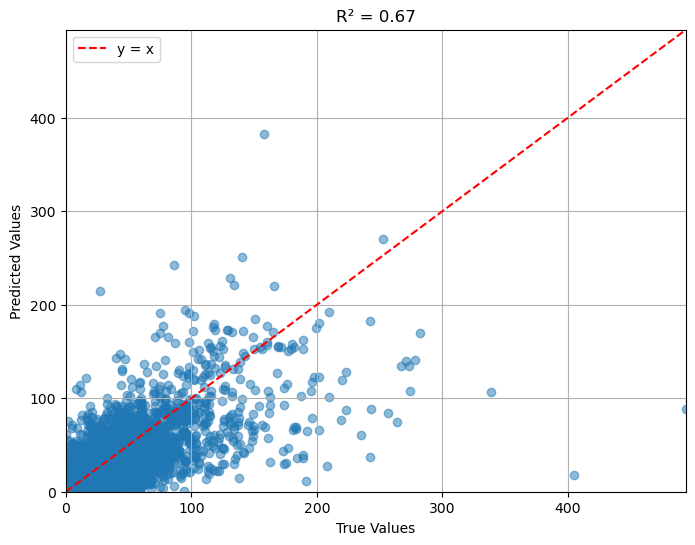

In [17]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(dataset.X.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, dataset.X.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = dataset.X[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


In [18]:
rho = trace.nodes["rho"]["value"]
print(rho.shape)
#rho_at_P = rho[batch_indices, P, :]  # shape: [batch, latent_dim]

#data.obsm['rho'] = rho_at_P.detach().cpu().numpy()


torch.Size([100, 16])


In [20]:
z = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

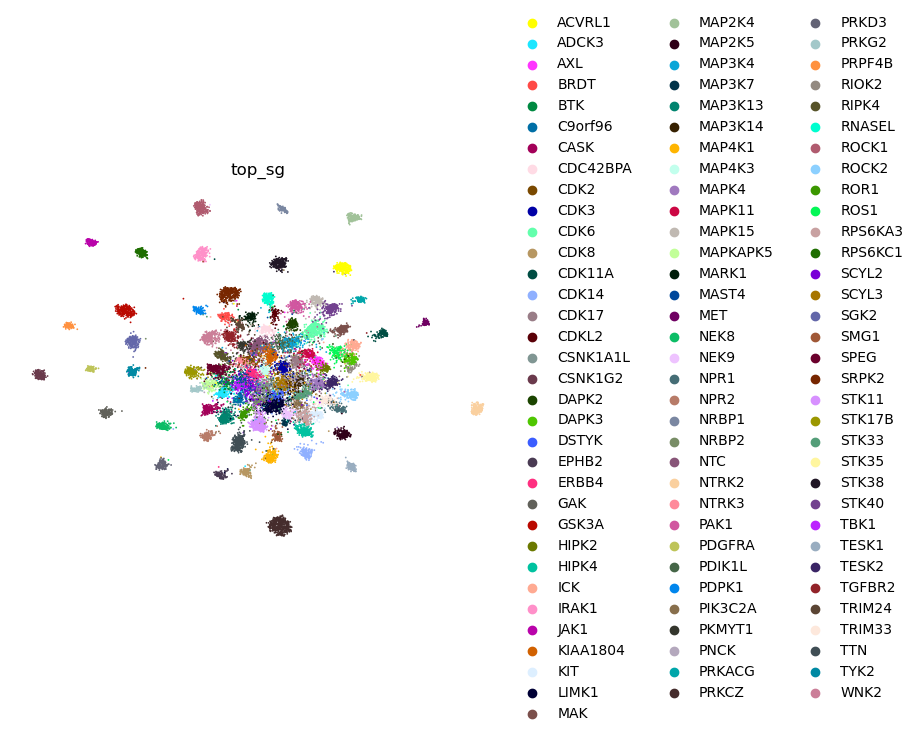

In [21]:
z_data = data.copy()
z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, use_rep='z', n_neighbors=15)
sc.tl.umap(z_data)
sc.pl.umap(z_data, color=['top_sg'], frameon=False, show=True)

In [22]:
z0_data = data.copy()
z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='z0', n_neighbors=15)
sc.tl.umap(z0_data)

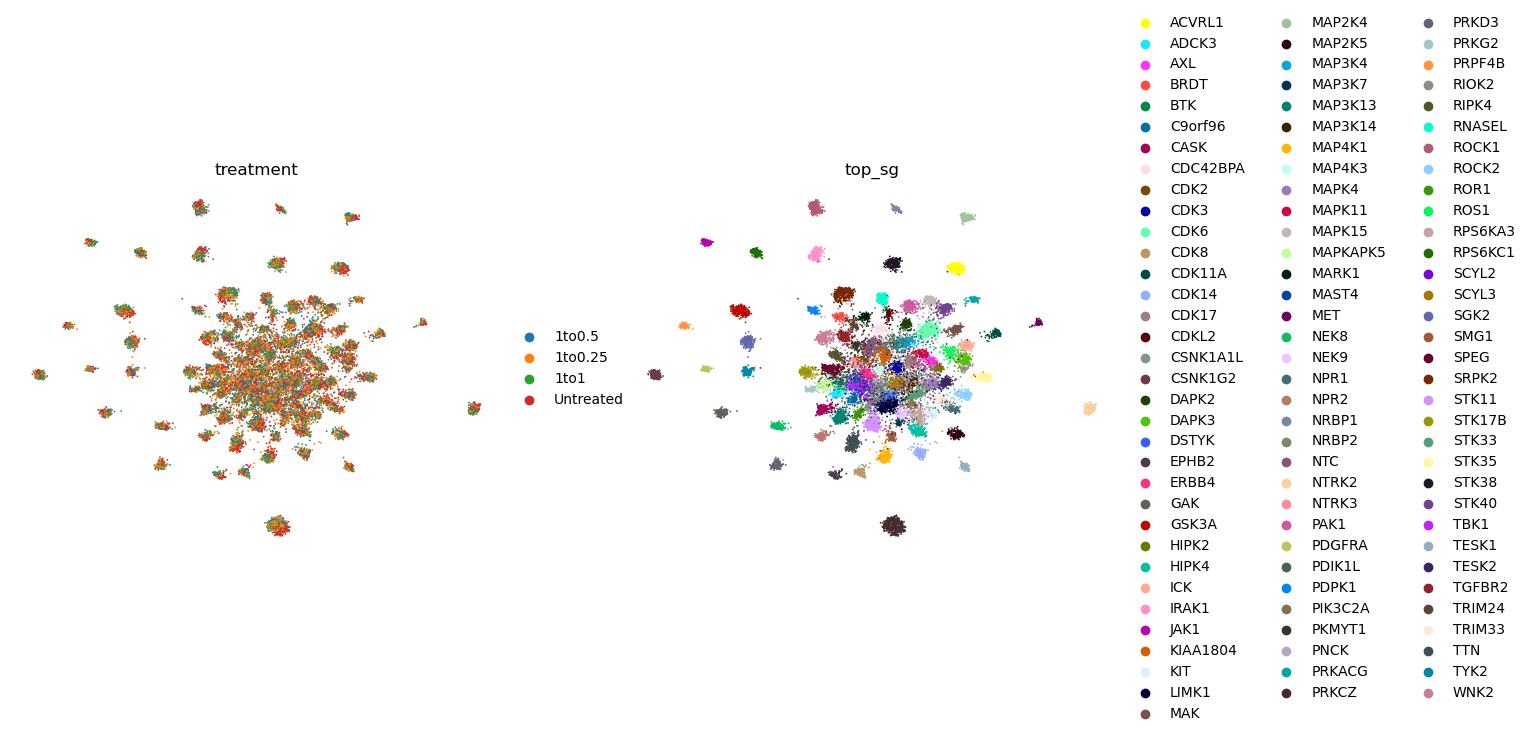

In [23]:
sc.pl.umap(z_data, color=['treatment', 'top_sg'], frameon=False, show=True)

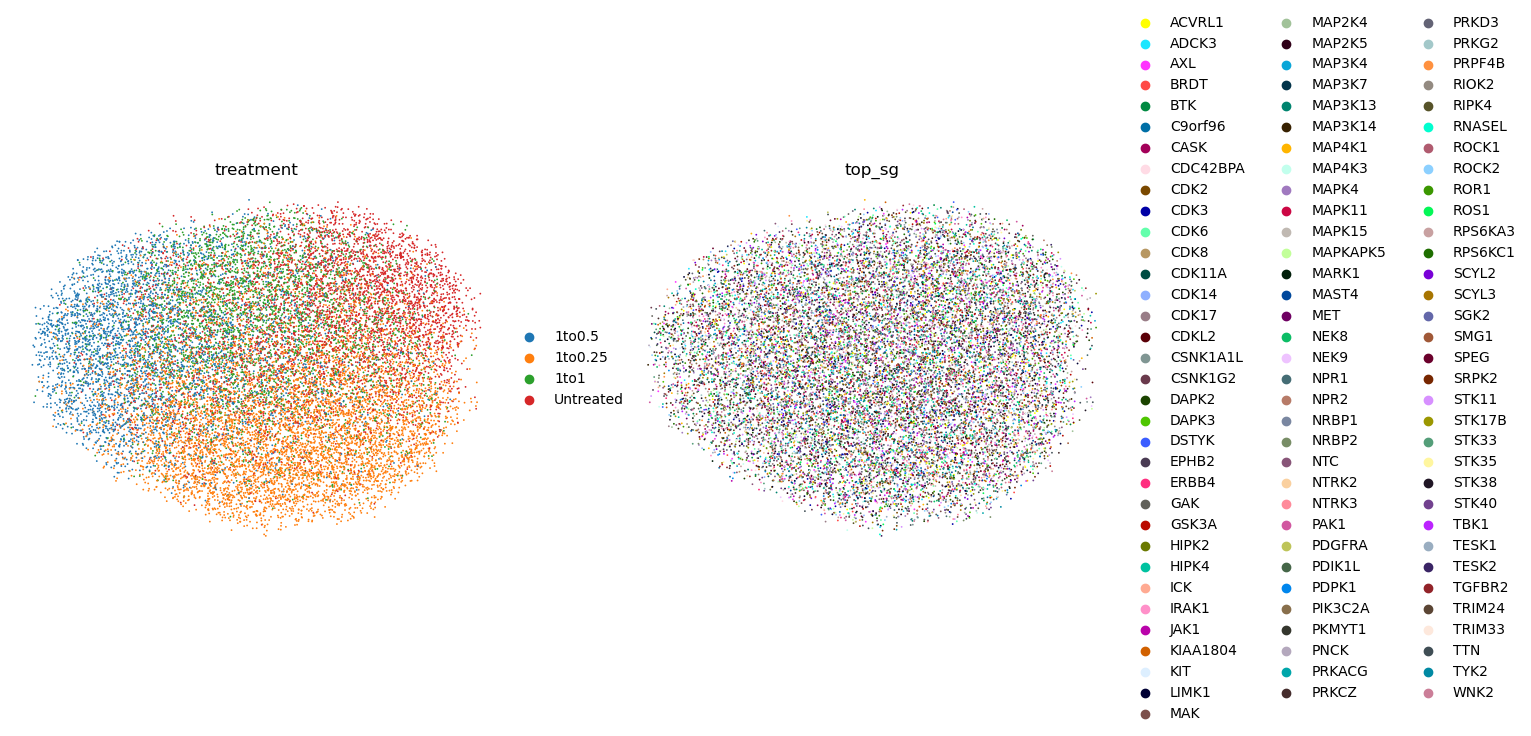

In [24]:
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

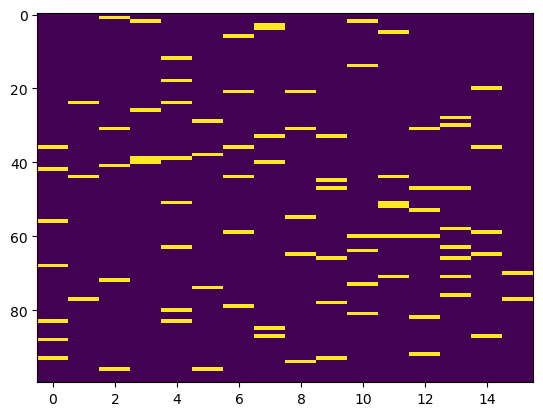

In [24]:
s_gate = trace.nodes["s_gate"]['value']
plt.imshow(s_gate.detach().cpu().numpy(), cmap='viridis', aspect='auto')

In [25]:
pi = trace.nodes["pi"]['value']
pi

tensor([0.0522, 0.0517, 0.0510, 0.0508, 0.0504, 0.0515, 0.0482, 0.0497, 0.0489,
        0.0499, 0.0484, 0.0495, 0.0516, 0.0491, 0.0490, 0.0501],
       grad_fn=<ExpandBackward0>)

In [26]:
pyro.get_param_store()['q_pi']

tensor([0.0522, 0.0517, 0.0510, 0.0508, 0.0504, 0.0515, 0.0482, 0.0497, 0.0489,
        0.0499, 0.0484, 0.0495, 0.0516, 0.0491, 0.0490, 0.0501],
       grad_fn=<ClampBackward1>)

# Check W consistency

In [13]:
def _initialize_vaes(dataset, gene_module_dict, n_models=5):
    vaes = []
    for _ in range(n_models):
        # Initialize a new VAE for each model
        input_dim = data.shape[-1] 
        latent_dim = len(gene_module_dict.keys())
        vae = VAE(input_dim, latent_dim, 
                  len(np.unique(dataset.P_indices)),
                  len(np.unique(dataset.C_indices)),
                  100, module_dict=gene_module_dict,
                  center_coeff_init=1e-2)
        vae = vae.to(vae.device)
        vaes.append(vae)
    return vaes

In [14]:
models = _initialize_vaes(dataset, gene_module_dict, n_models=5)

In [15]:
import tqdm

In [16]:
for i in tqdm.tqdm(range(len(models))):
    trainer = VAETrainer(
        models[i],
        dataloader,
        lr=1e-3,
        num_epochs=20,
        init_coeff=models[i].center_coeff_init,                 
        final_coeff=1e-1,                 
        ramp_steps=10000,
        tau_init=1.0,
        tau_end=0.1,
        tau_anneal_steps=10000,
        verbose=False,
        seed=i + 42
    )
    trainer.fit()

  0%|                                                                                                                                 | 0/5 [00:00<?, ?it/s]

Training VAE on cuda …


 20%|████████████████████████                                                                                                | 1/5 [05:20<21:23, 320.85s/it]

Training VAE on cuda …


 40%|████████████████████████████████████████████████                                                                        | 2/5 [10:43<16:05, 321.93s/it]

...

 60%|████████████████████████████████████████████████████████████████████████                                                | 3/5 [16:02<10:41, 320.71s/it]

Training VAE on cuda …


 80%|████████████████████████████████████████████████████████████████████████████████████████████████                        | 4/5 [21:21<05:19, 319.86s/it]

Training VAE on cuda …


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [26:40<00:00, 320.15s/it]


In [17]:
from utils import *

In [18]:
def _model_trace(model, dataset):
    model.eval()
    model.device = torch.device('cpu')
    model = model.to(model.device)
    print(model.device)

    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):        # list() -> safe while mutating
        param_store[name] = value.to(torch.device('cpu'))             # keep grad history

    X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

    trace = poutine.trace(model.guide).get_trace(X, P, C)
    trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X, P, C)
    return trace, trace_model

In [19]:
Ws, Pis = [], []             # graph-level statistics
Zs, Z0s, Rhos = [], [], []    # optional latent diagnostics

for run_idx, vae in enumerate(tqdm.tqdm(models, desc="collect posteriors")):

    # --------  move model + params to CPU and eval mode  ----------
    vae.eval()
    vae.to("cpu")
    pyro.get_param_store()         # keep gradients intact if needed

    q_pi = pyro.param("q_pi").detach().clone()        # shape (d,)
    print(torch.mean(q_pi))
    print(torch.max(q_pi))
    Pis.append(q_pi)
    S_map = get_bipartite_graph(mode="weighted", threshold=0.5)
    Ws.append(S_map)

    # --------  draw one trace if you want latent snapshots  -------
    X = torch.tensor(dataset.X)
    P = torch.tensor(dataset.P_indices)
    C = torch.tensor(dataset.C_indices)

    trace = pyro.poutine.trace(vae.guide).get_trace(X, P, C)

    Zs.append(trace.nodes["z"]["value"].detach().cpu())
    Z0s.append(trace.nodes["z0"]["value"].detach().cpu())
    Rhos.append(trace.nodes["rho"]["value"].detach().cpu())


collect posteriors:   0%|                                                                                                             | 0/5 [00:00<?, ?it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  20%|████████████████████▏                                                                                | 1/5 [00:00<00:01,  2.20it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  40%|████████████████████████████████████████▍                                                            | 2/5 [00:00<00:01,  2.17it/s]

...

collect posteriors:  60%|████████████████████████████████████████████████████████████▌                                        | 3/5 [00:01<00:00,  2.30it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  80%|████████████████████████████████████████████████████████████████████████████████▊                    | 4/5 [00:01<00:00,  2.33it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.32it/s]


In [22]:
from __future__ import annotations
import itertools, math
import torch, pyro, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
from typing import Sequence, Union

def _qpi_to_numpy(model) -> np.ndarray:
    """
    Fetch q_pi from a trained model and return (P,d) numpy array.
    Assumes model already uses canonicalise_columns_by_module().
    """
    q = pyro.param("q_pi", model.device).detach().cpu().numpy()
    return q


def compare_and_plot_pi(models   : Sequence[torch.nn.Module],
                        thresh   : float = 0.5,
                        cmap     : str = "Blues",
                        figsize  : tuple[int, int] | None = None):

    # ----------  collect q_pi  ------------------------------------
    Qs = [_qpi_to_numpy(m) for m in models]        # list of (P,d)
    R  = len(Qs)
    flat_Q = [q.flatten() for q in Qs]             # make 1D for corr

    # ----------  pairwise Pearson matrix --------------------------
    Pcorr = np.ones((R, R))
    for (i, q_i), (j, q_j) in itertools.combinations(enumerate(flat_Q), 2):
        corr = np.corrcoef(q_i, q_j)[0, 1]
        Pcorr[i, j] = Pcorr[j, i] = corr

    # ----------  prepare average & binary graph -------------------
    Q_mean  = np.stack(Qs).mean(0)                 # (P,d)
    Q_bin   = (Q_mean >= thresh).astype(int)       # 0/1 graph

    # ----------  plotting -----------------------------------------
    if figsize is None:
        figsize = (4*R, 4 + 1.5)       # heat-map strip + two little panels
    fig = plt.figure(figsize=figsize)

    # A) correlation heat-map
    ax0 = plt.subplot2grid((1, R+1), (0, 0), colspan=R)
    sns.heatmap(Pcorr, vmin=0, vmax=1, cmap="viridis",
                annot=True, fmt=".2f", square=True, ax=ax0,
                cbar_kws={"label": "Pearson r"})
    ax0.set_title("q_pi consistency across runs")
    ax0.set_xlabel("run"); ax0.set_ylabel("run")

    # B) average probability matrix
    ax1 = plt.subplot2grid((1, R+1), (0, R))
    sns.heatmap(Q_mean, cmap=cmap, square=False,
                cbar=True, ax=ax1)
    ax1.set_title("mean q_pi")
    ax1.set_xlabel("latent dim"); ax1.set_ylabel("perturbation")

    # C) binary bipartite graph (thresholded)
    fig2, ax2 = plt.subplots(figsize=(3, 4))
    sns.heatmap(Q_bin, cmap="Greys", cbar=False, ax=ax2)
    ax2.set_title(f"bipartite graph  (≥{thresh})")
    ax2.set_xlabel("latent dim"); ax2.set_ylabel("perturbation")
    plt.tight_layout()
    plt.show(block=False)

    return Pcorr, Q_mean, Q_bin

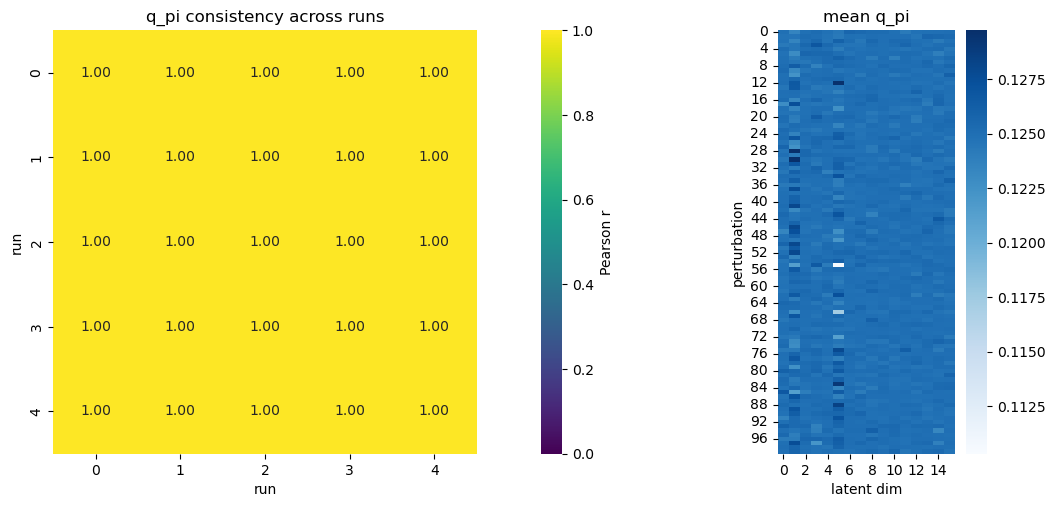

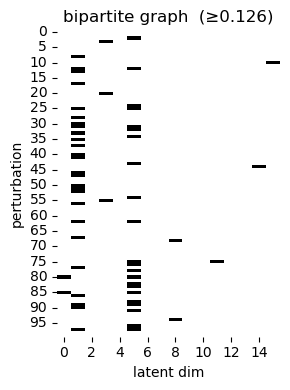

In [26]:
Pcorr, Q_mean, Q_bin = compare_and_plot_pi(models, thresh=0.126)

In [98]:
from utils import *

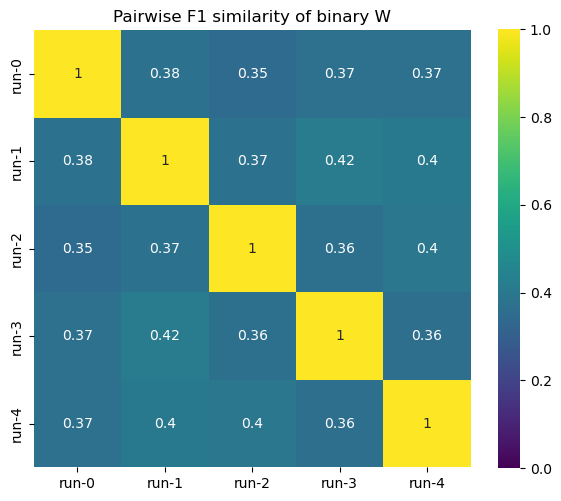

Mean f1 = 0.378 ± 0.020


In [ ]:
compare_W_runs_binary(, align=False)

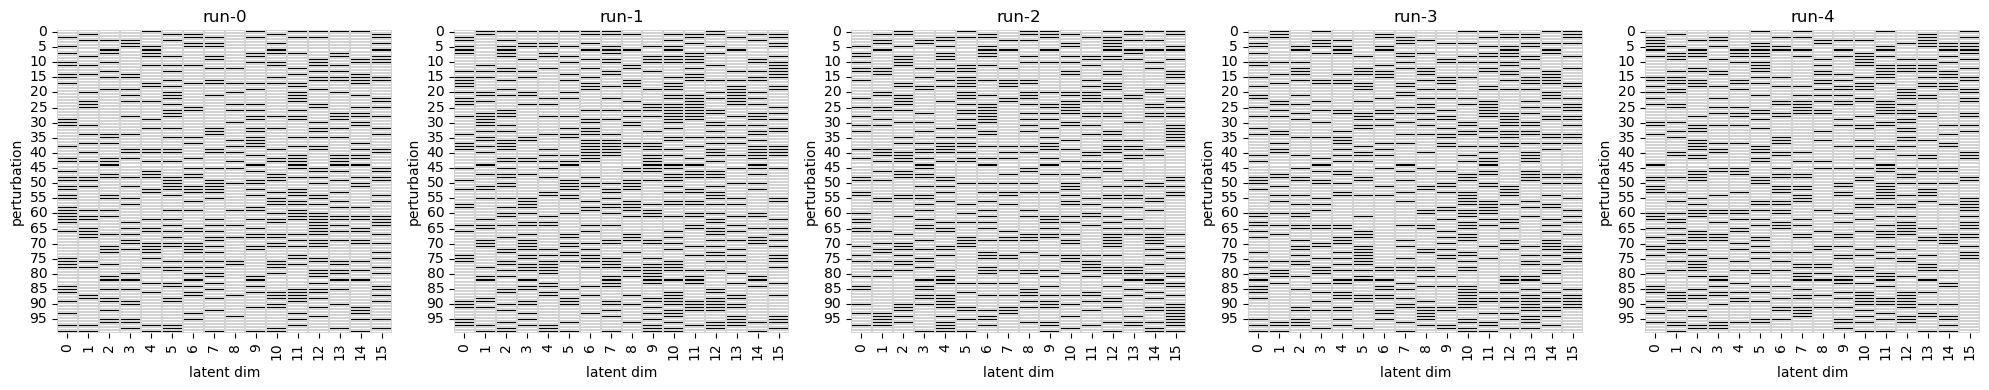

In [100]:
plot_binary_Ws(Ws)